In [6]:
import numpy as np
import matplotlib.pyplot as plt
import cv2

Process input

Text(0.5, 1.0, 'Original Image')

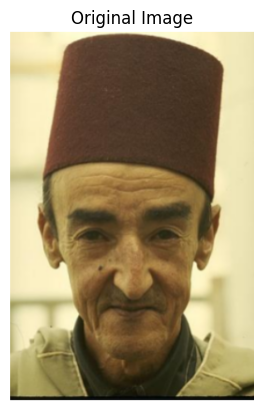

In [7]:
img = cv2.imread("image.png")
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB) #convert image from BGR to RGB
plt.imshow(img) #show the image
plt.axis("off")
plt.title("Original Image")

Conver image to grayscale using grayscale filter then apply median filter for noise reduction. Then detect edges using laplacian filter and binary threshold for either black or white outputs.
Median filter kernel size is 7 (7x7 window)
Laplacian produces produces 8 bit unsigned int image(0->255) (CV_8U)
Threshold: 128 is the threshold limit, 255 is the max value, invert the result because threshold gives values above threshold the value 0...


Text(0.5, 1.0, 'Thresholding applied')

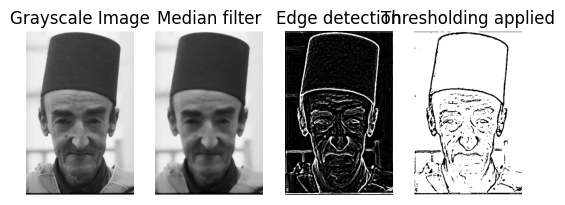

In [8]:
gray = cv2.cvtColor(img, cv2.COLOR_RGB2GRAY)

median=cv2.medianBlur(gray,7) #kernel size is 7 for sharp detection

laplacian=cv2.Laplacian(median,cv2.CV_8U, ksize=5) # (0->255)

_, edges = cv2.threshold(laplacian, 100, 255, cv2.THRESH_BINARY_INV) #invert black and white after threshold !


plt.subplot(1,4,1)
plt.imshow(gray, cmap='gray') #show the image
plt.axis("off")
plt.title("Grayscale Image")

plt.subplot(1,4,2)
plt.imshow(median, cmap='gray') #show the image
plt.axis("off")
plt.title("Median filter")

plt.subplot(1,4,3)
plt.imshow(laplacian, cmap='gray') #show the image
plt.axis("off")
plt.title("Edge detection")

plt.subplot(1,4,4)
plt.imshow(edges, cmap='gray') #show the image
plt.axis("off")
plt.title("Thresholding applied")

Bilateral filter: 9 is the neighbourhood diameter, 75 is color similarity and spatial smoothing. only mix colors id close in space(gauss) and similar in color


Text(0.5, 1.0, 'Bilateral filter applied')

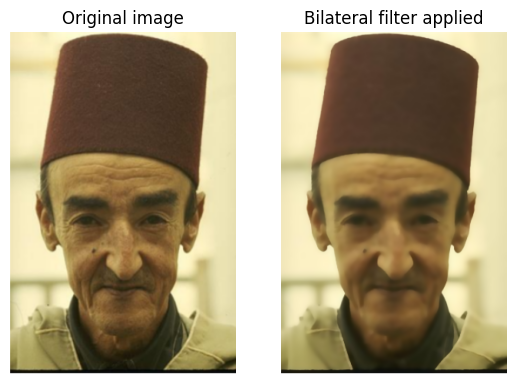

In [9]:
filtered = cv2.bilateralFilter(img, 9, 75, 75)
plt.subplot(1,2,1)
plt.imshow(img) #show the image
plt.axis("off")
plt.title("Original image")
plt.subplot(1,2,2)
plt.imshow(filtered) #show the image
plt.axis("off")
plt.title("Bilateral filter applied")

Creating the final cartoon image

Text(0.5, 1.0, 'Cartoon output')

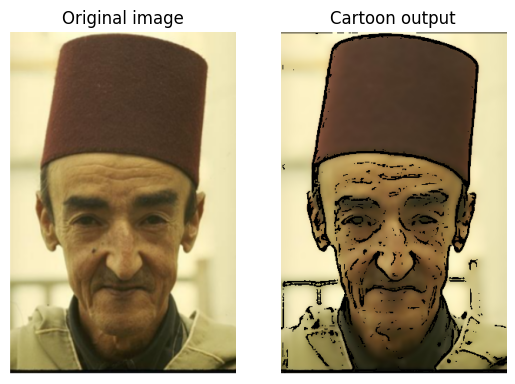

In [10]:
cartoon = cv2.bitwise_and(filtered, filtered, mask=edges)
plt.subplot(1,2,1)
plt.imshow(img) #show the image
plt.axis("off")
plt.title("Original image")
plt.subplot(1,2,2)
plt.imshow(cartoon) #show the image
plt.axis("off")
plt.title("Cartoon output")